SDS210-Project: An analysis of the "Züri Wie Neu" data

In [3]:
import pandas as pd
import geopandas as gpd

#read data (all datasets which are necessary to answer questions 1-4) 
#if necessary create subsets to reduce the size of the data
meldungen_csv = gpd.read_file("data/raw/stzh.zwn_meldungen_p.json") #name a bit misleading, but used in the code too many times to change now
meldungen_csv = meldungen_csv[["objectid", "requested_datetime", "e", "n", "service_code", "geometry"]]

quartiere_json = gpd.read_file("data/raw/stzh.adm_statistische_quartiere_v.json")
quartiere_csv = gpd.read_file("data/raw/stzh.adm_statistische_quartiere_v.csv")

fläche_csv = pd.read_csv("data/raw/bevölkerung_zh2.csv")
fläche_csv = fläche_csv[["RaumKategorie", "RaumSort", "RaumLang", "FlaecheT"]]


Quick overview on the datasets (can be skipped or commented, but important to see what we are working with)

In [ ]:
#overview of columns of different datasets 
print("Meldungen CSV:", meldungen_csv.columns)
print("Quartiere JSON:", quartiere_json.columns)
print("Quartiere CSV", quartiere_csv.columns)
print("Fläche CSV:", fläche_csv.columns)

Meldungen CSV: Index(['objectid', 'service_request_id', 'requested_datetime',
       'agency_sent_datetime', 'updated_datetime', 'e', 'n', 'service_code',
       'service_name', 'status', 'userid', 'title', 'detail', 'media_url',
       'interface_used', 'service_notice', 'description', 'url', 'geometry'],
      dtype='str')
Quartiere JSON: Index(['objid', 'objectid', 'geometry'], dtype='str')
Quartiere CSV Index(['objid', 'objectid', 'qname', 'qnr', 'kname', 'knr', 'geometry'], dtype='str')
Fläche CSV: Index(['RaumKategorie', 'RaumSort', 'RaumLang', 'StichtagDatJahr', 'FlaecheT',
       'FlaecheL', 'FlaecheS'],
      dtype='str')


Question 1a: Wich is the category with the highest number of reports?  

In [4]:
#count the number of reports per category (service_code)
anzahl_meldungen = meldungen_csv.groupby("service_code").size().reset_index(name = "anzahl_meldungen")


#sort it and display to answer the question 
display(anzahl_meldungen.sort_values("anzahl_meldungen", ascending = False))

,service_code,anzahl_meldungen
0,Abfall/Sammelstelle,27339
7,Signalisation/Lichtsignal,10975
8,Strasse/Trottoir/Platz,9870
5,Grünflächen/Spielplätze,7238
2,Beleuchtung/Uhren,5407
1,Allgemein,3969
4,Graffiti,3759
9,VBZ/ÖV,1882
3,Brunnen/Hydranten,1289
6,Schädlinge,895


Question 1b: Which are the top 3 'Quartiere'/'Kreise' with the most reports? 

In [6]:
from shapely.geometry import Point
import geopandas as gpd

#ensure the correct CRS
quartiere_ch = quartiere_json.to_crs(epsg = 2056)


#merge quartiere_json and _csv to combine spatial data and important attributes (+ set active geometry)
quartiere_gdf = quartiere_json.merge(
    quartiere_csv, on = "objid", how = "left").set_geometry("geometry_x").to_crs(epsg = 2056) 


#create geometries from meldungen_csv
meldungen_gdf = gpd.GeoDataFrame(
    meldungen_csv,
    geometry=gpd.points_from_xy(meldungen_csv["e"], meldungen_csv["n"]),
    crs=quartiere_ch.crs)
meldungen_ch = meldungen_gdf.to_crs(epsg = 2056)


#spatial join of meldungen und quartiere
meldungen_quartier_join = gpd.sjoin(
    meldungen_ch, #left
    quartiere_gdf, #right
    how = "inner", predicate = "intersects")


#calculate number of reports (meldungen) per 'Quartier' and 'Kreis' 
meldungen_pro_quartier = (meldungen_quartier_join.groupby("qname").size().reset_index(name = "anzahl_meldungen_quartier"))
display(meldungen_pro_quartier.sort_values("anzahl_meldungen_quartier", ascending = False)) #could add .head(3) to only see the top 3 quartiere, but as I want to get to know the data, I leave it away here

meldungen_pro_kreis = (meldungen_quartier_join.groupby("kname").size().reset_index(name = "anzahl_meldungen_kreis"))
display(meldungen_pro_kreis.sort_values("anzahl_meldungen_kreis", ascending = False))


#add the newly calculated values to the join 
meldungen_quartier_join = meldungen_quartier_join.merge(
    meldungen_pro_kreis,
    on = "kname",
    how = "left")

meldungen_quartier_join = meldungen_quartier_join.merge(
    meldungen_pro_quartier,
    on = "qname",
    how = "left")

#again reduce the number of attributes 
meldungen_quartier_join = meldungen_quartier_join[["objectid", "requested_datetime", "e", "n", "service_code", "geometry", "index_right", "qname", "qnr", "kname", "knr", "geometry_y", "anzahl_meldungen_quartier", "anzahl_meldungen_kreis"]]


,qname,anzahl_meldungen_quartier
16,Langstrasse,6185
27,Sihlfeld,5235
3,Altstetten,4094
28,Unterstrass,3594
31,Wipkingen,3304
15,Höngg,3090
21,Oerlikon,2985
10,Hard,2855
33,Wollishofen,2837
5,Enge,2756


,kname,anzahl_meldungen_kreis
6,Kreis 4,10569
5,Kreis 3,9152
2,Kreis 11,8026
1,Kreis 10,6394
4,Kreis 2,6225
11,Kreis 9,6142
0,Kreis 1,5738
9,Kreis 7,5714
8,Kreis 6,5110
7,Kreis 5,3792


Question 2: Is the density of reports higher around the lake than elsewhere? 
Assumption: "Around the lake" includes 'Kreise' 1,2 and 8

In [7]:
#create subsets to reduce the size of the datasets 
quartiere_subset = quartiere_gdf[["objid", "geometry_x", "kname", "knr"]]

fläche_subset = fläche_csv[fläche_csv["RaumLang"].str.contains("Kreis", na = False)]


#join the fläche_subset with the meldungen_quartier_join
join_fläche_meldungen = fläche_subset.merge(
    meldungen_quartier_join[["kname", "anzahl_meldungen_kreis"]],
    left_on = "RaumLang", 
    right_on = "kname", 
    how = "left")


#calculate the report density per area (here:hectares)
join_fläche_meldungen["meldungsdichte_kreis"] = join_fläche_meldungen["anzahl_meldungen_kreis"]/join_fläche_meldungen["FlaecheT"]


#merge the report density with the meldungen_quartier_join 
quartiere_subset = quartiere_subset.merge(
    join_fläche_meldungen[["meldungsdichte_kreis", "RaumLang"]],
    left_on = "kname", 
    right_on = "RaumLang",
    how = "inner")


#as long as the visualization does not work, let's do it with a table for the moment
quartiere_subset_table = quartiere_subset[["meldungsdichte_kreis", "kname"]].groupby("kname").mean()
display(quartiere_subset_table.sort_values("meldungsdichte_kreis", ascending = False))


,meldungsdichte_kreis
kname,
Kreis 4,36.627191
Kreis 1,31.803732
Kreis 5,18.852117
Kreis 3,10.579484
Kreis 6,10.014646
Kreis 10,7.036707
Kreis 8,6.245708
Kreis 11,5.976069
Kreis 2,5.624177


visualization to question 2 

PROBLEM: GEIT NED, STÜRZT AB SOBAUD IS WETT PLOTTE

In [ ]:
#create the empty subplots 
fig, ax = plt.subplots(figsize=(10, 8)) #set up figure and axes


#create a legend 
legend_options = {
    "label": "Report Density per Kreis Normalized per Area (Hectares)",
    "orientation": "horizontal",
    "shrink": 0.6,
    "pad" : 0.05}


#combine the previous elements to a plot
charte_plot = quartiere_subset.plot(
    ax = ax, 
    column = "meldungsdichte_kreis",
    cmap = "viridis",
    legend = True,
    legend_kwds = legend_options,
    edgecolor = "grey",
    linewidth = 0.1)


Question 3: How does the report density differ between august (summer) and january (winter)?

In [13]:
import geopandas as gpd
import pandas as pd

# parse date in meldungen_quartier_join
meldungen_quartier_join["requested_datetime"] = pd.to_datetime(
    meldungen_quartier_join["requested_datetime"], format = "%Y%m%d%H%M%S")


#create a subset which only contains the data about the 'Kreise' around the lake (1,2,8)
kreise_see = meldungen_quartier_join[meldungen_quartier_join["knr"].isin(["1", "2", "8"])]


#compare number of reports in august and january manually 
august = meldungen_quartier_join[(meldungen_quartier_join["requested_datetime"] >= "2023-08-01") & 
                                 (meldungen_quartier_join["requested_datetime"] < "2023-09-01")].copy()
januar = meldungen_quartier_join[(meldungen_quartier_join["requested_datetime"] >= "2023-01-01") & 
                                 (meldungen_quartier_join["requested_datetime"] < "2023-02-01")].copy()

print(f"Number of Reports in August 2023: {len(august)}")
print(f"Number of Reports in January 2023: {len(januar)}")

#create a function to filter the reports per month and year
def filter_by_month(data, year = None, month = None):
    """
    define a function that filters the input data by year and month
    ---
    parameters
    data: pd.DataFrame of "Züri Wie Neu" reports that contains a column name 'requested_datetime' with datetime values (parsed dates follow the format 01-01-2000)
    year: int, optional, for filtering, between 2013 and 2026, if None: no filtering by year applied
    month: int, optional, for filtering, between 1 and 12, if None: no filtering by month applied
    ---
    returns
    pd.DataFrame
    filtered dataframe only containing the rows that match the specified month and year 3 
    """
    result = data.copy()

    if year is not None:
        result = result[result["requested_datetime"].dt.year == year]

    if month is not None:
        result = result[result["requested_datetime"].dt.month == month] 

    return result

#apply function to filter august and january data
august_daten = filter_by_month(meldungen_quartier_join, month = 8)
januar_daten = filter_by_month(meldungen_quartier_join, month = 1)



Number of Reports in August 2023: 775
Number of Reports in January 2023: 442


Question 3: Visualization 

(np.float64(2675552.6387122865),
 np.float64(2690337.8685234124),
 np.float64(1240947.9997338506),
 np.float64(1254942.3405427965))

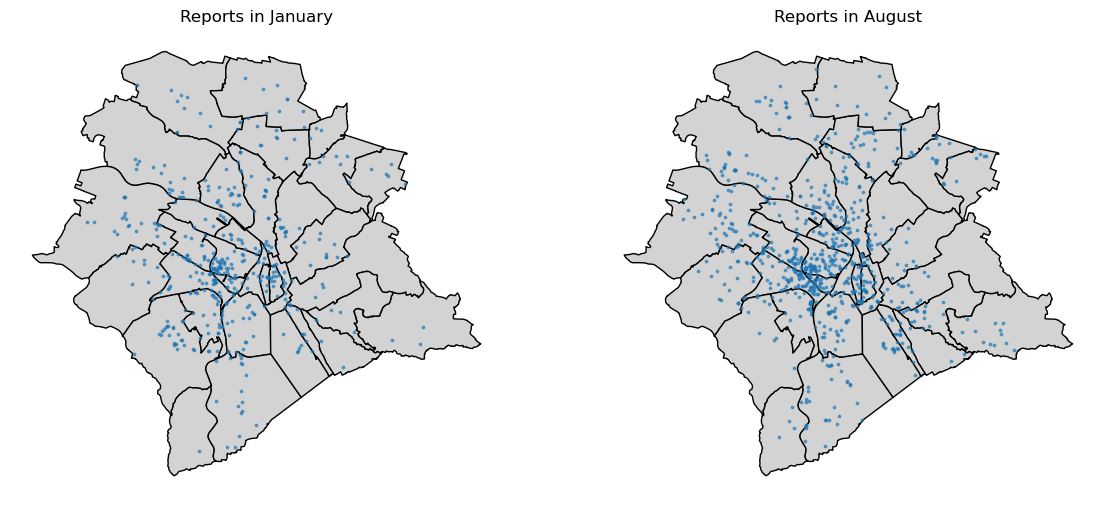

In [19]:

import matplotlib.pyplot as plt

#create figure with 2 plots next to each other
fig, ax = plt.subplots(1, 2, figsize = (14, 7))

#plot january
quartiere_gdf.plot(
    ax = ax[0],
    color = "lightgrey",
    edgecolor = "black")

januar.plot(
    ax = ax[0], 
    markersize = 3,
    alpha = 0.6)

ax[0].set_title(f"Reports in January")
ax[0].axis("off")

#plot august
quartiere_gdf.plot(
    ax = ax[1],
    color = "lightgrey",
    edgecolor = "black")

august.plot(
    ax = ax[1], 
    markersize = 3,
    alpha = 0.6)

ax[1].set_title("Reports in August")
ax[1].axis("off")

Question 4: Which trend does the august (summer) data around the lake show within the report period?

PROBLEM: CHANI ERST RICHTIG FERTIG MACHE WENN D FUNKTION VO QUESTION 3 FUNKTIONIERT

In [ ]:
import numpy as np
import pandas as pd

#check Index to ensure data is ready to resample 
print(f"August Index: {august_daten.index}") #DatetimeIndex (dtype = 'datetype64', name = 'requested_datetime')


#resample monthly mean temperatures 
august_daten["august_mean"] = august_daten["anzahl_meldungen_kreis"].resample("ME").mean().dropna()

augusts_passed = np.arange(len(august_mean))

slope, intercept = np.polyfit(augusts_passed, august_mean, 1)

print(f"long-term request trend: {slope:.3f} per year")
print(f"total change of number of requests over the dataset: {(slope * len(augusts_passed)):.2f}")

August Index: DatetimeIndex(['2023-08-08 16:39:04', '2023-08-08 22:57:52',
               '2023-08-02 16:28:36', '2023-08-04 14:45:19',
               '2023-08-09 12:48:30', '2023-08-09 12:49:06',
               '2023-08-01 09:12:51', '2023-08-01 13:49:49',
               '2023-08-01 15:31:45', '2023-08-01 15:31:59',
               ...
               '2023-08-31 16:59:47', '2023-08-31 17:00:53',
               '2023-08-31 17:01:51', '2023-08-31 17:03:08',
               '2023-08-31 17:04:41', '2023-08-31 17:07:14',
               '2023-08-31 17:08:31', '2023-08-31 18:46:36',
               '2023-08-31 20:15:23', '2023-08-31 21:31:14'],
              dtype='datetime64[us]', name='requested_datetime', length=775, freq=None)


c:\Users\User\miniconda3\envs\sds210\Lib\site-packages\numpy\lib\_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares